In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
})

Tc = 2 / np.log(1 + np.sqrt(2))
L_values = [10, 20, 30, 40, 60]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(L_values)))

plot validation loss versus epoch for each lattice size.

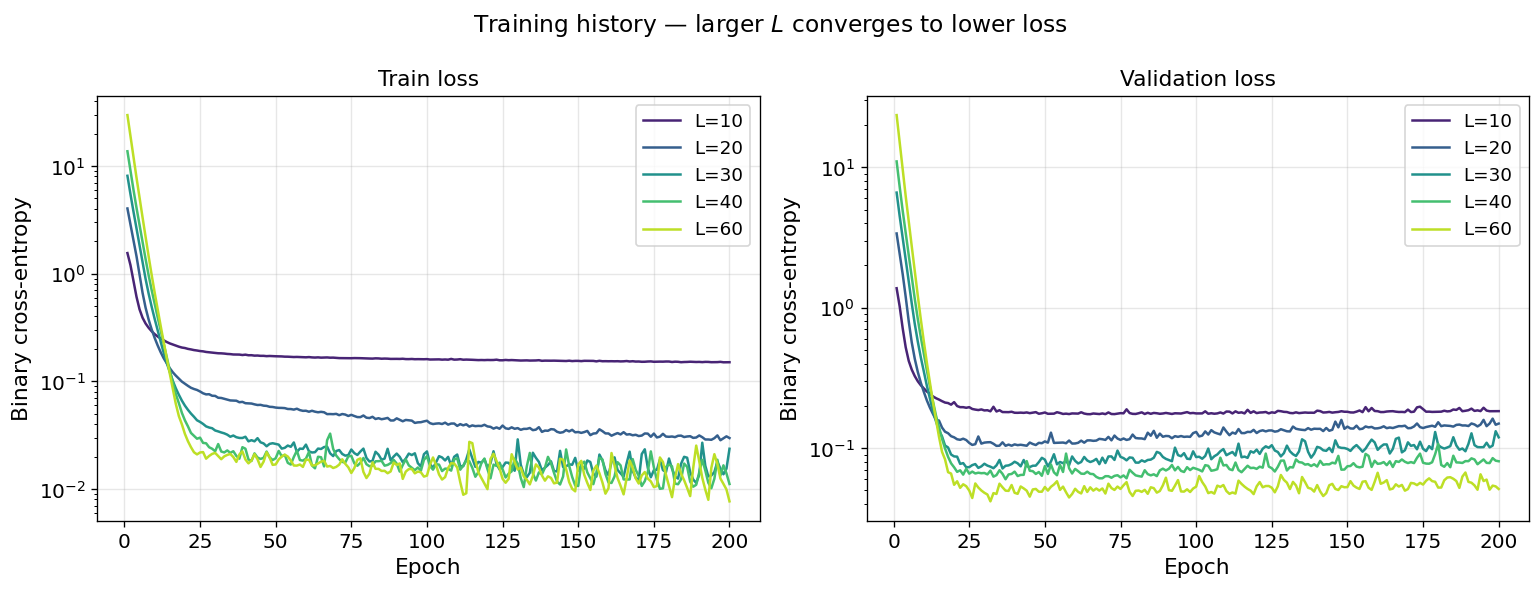

In [19]:
histories = {}
for L in L_values:
    with open(f'training_history_100/L{L}.json') as f:
        histories[L] = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, key, ylabel in zip(axes, ['loss', 'val_loss'], ['Train loss', 'Validation loss']):
    for L, c in zip(L_values, colors):
        h = histories[L][key]
        ax.plot(range(1, len(h)+1), h, color=c, label=f'L={L}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Binary cross-entropy')
    ax.set_title(ylabel)
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.suptitle('Training history — larger $L$ converges to lower loss', fontsize=14)
plt.tight_layout()
#plt.savefig('loss_curves.pdf', bbox_inches='tight')
plt.show()

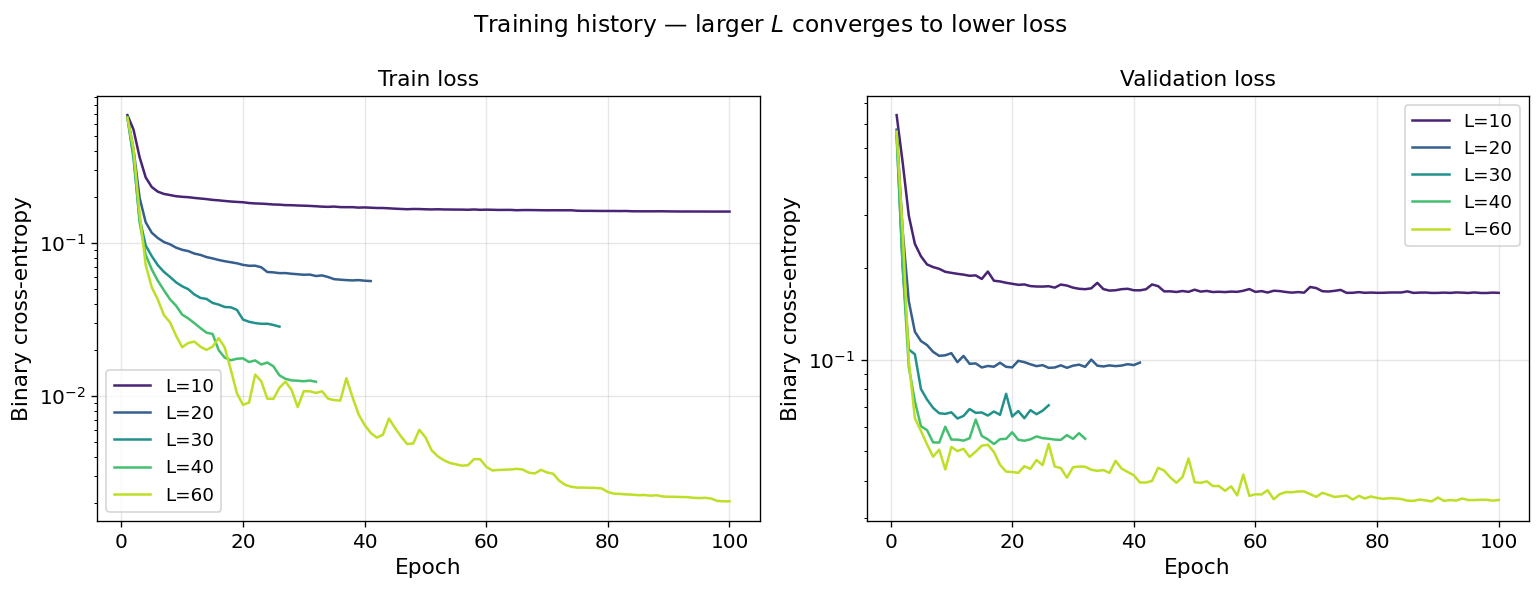

In [21]:
histories = {}
for L in L_values:
    with open(f'models_100_op/training_history_100_op/L{L}.json') as f:
        histories[L] = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, key, ylabel in zip(axes, ['loss', 'val_loss'], ['Train loss', 'Validation loss']):
    for L, c in zip(L_values, colors):
        h = histories[L][key]
        ax.plot(range(1, len(h)+1), h, color=c, label=f'L={L}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Binary cross-entropy')
    ax.set_title(ylabel)
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.suptitle('Training history — larger $L$ converges to lower loss', fontsize=14)
plt.tight_layout()
#plt.savefig('loss_curves.pdf', bbox_inches='tight')
plt.show()

Extract the minimum validation loss achieved for each $L$ and check whether it follows a power law.

Power-law fit: min val_loss ~ L^-0.80


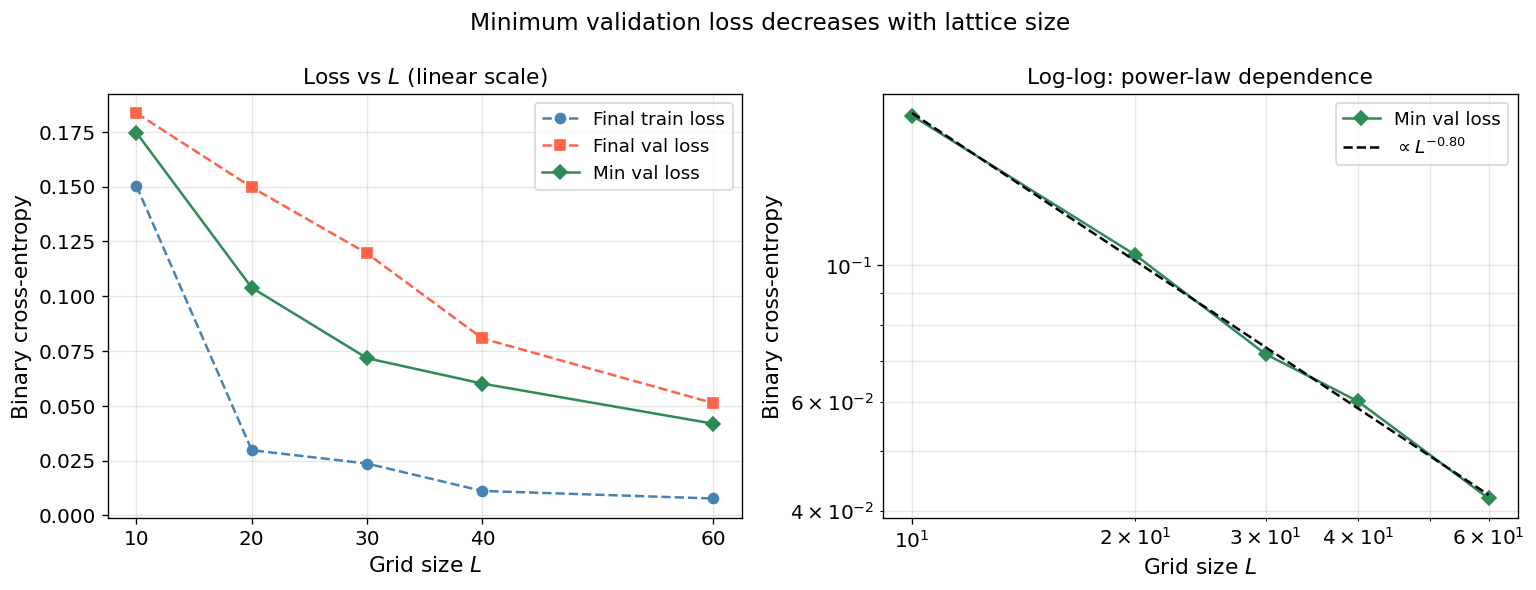


Summary table:
    L  min val loss  final train loss
   10        0.1746            0.1504
   20        0.1039            0.0297
   30        0.0717            0.0236
   40        0.0601            0.0111
   60        0.0418            0.0077


In [ ]:
min_val_loss  = {L: min(histories[L]['val_loss'])  for L in L_values}
final_val_loss = {L: histories[L]['val_loss'][-1]  for L in L_values}
final_train_loss = {L: histories[L]['loss'][-1]    for L in L_values}

Ls = np.array(L_values)
mv = np.array([min_val_loss[L] for L in L_values])
fv = np.array([final_val_loss[L] for L in L_values])
ft = np.array([final_train_loss[L] for L in L_values])

# Fit power law: log(loss) = a + b*log(L)
slope, intercept = np.polyfit(np.log(Ls), np.log(mv), 1)
print(f'Power-law fit: min val_loss ~ L^{slope:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- linear axes ---
ax = axes[0]
ax.plot(Ls, ft, 'o--', color='steelblue',  label='Final train loss')
ax.plot(Ls, fv, 's--', color='tomato',     label='Final val loss')
ax.plot(Ls, mv, 'D-',  color='seagreen',   label='Min val loss')
ax.set_xlabel('Grid size $L$')
ax.set_ylabel('Binary cross-entropy')
ax.set_title('Loss vs $L$ (linear scale)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(Ls)

# --- log-log axes with power-law fit ---
ax = axes[1]
ax.loglog(Ls, mv, 'D-', color='seagreen', label='Min val loss')
L_fit = np.linspace(Ls.min(), Ls.max(), 100)
ax.loglog(L_fit, np.exp(intercept) * L_fit**slope, 'k--',
          label=f'$\\propto L^{{{slope:.2f}}}$')
ax.set_xlabel('Grid size $L$')
ax.set_ylabel('Binary cross-entropy')
ax.set_title('Log-log: power-law dependence')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Minimum validation loss decreases with lattice size', fontsize=14)
plt.tight_layout()
#plt.savefig('loss_vs_L.pdf', bbox_inches='tight')
plt.show()

print('\nSummary table:')
print(f'{"L":>5}  {"min val loss":>12}  {"final train loss":>16}')
for L in L_values:
    print(f'{L:>5}  {min_val_loss[L]:>12.4f}  {final_train_loss[L]:>16.4f}')

Power-law fit: min val_loss ~ L^-0.87


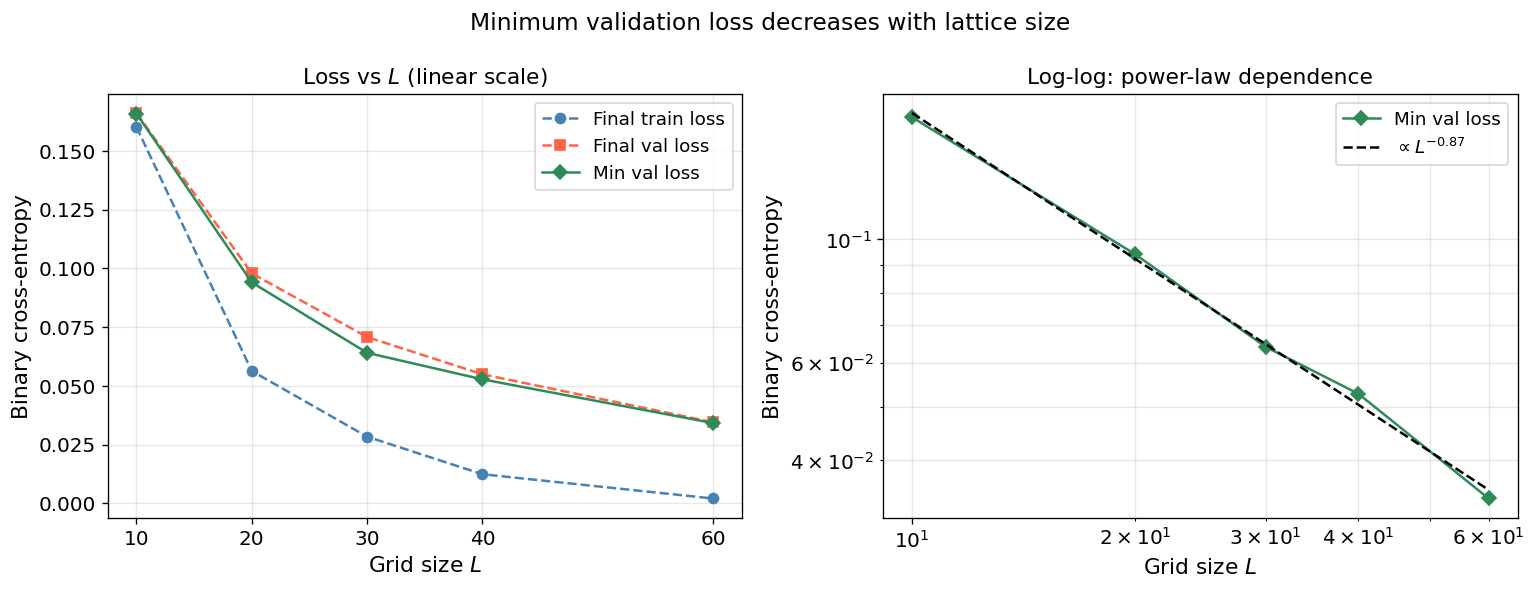


Summary table:
    L  min val loss  final train loss
   10        0.1659            0.1602
   20        0.0940            0.0563
   30        0.0640            0.0284
   40        0.0528            0.0124
   60        0.0342            0.0020


In [22]:
min_val_loss  = {L: min(histories[L]['val_loss'])  for L in L_values}
final_val_loss = {L: histories[L]['val_loss'][-1]  for L in L_values}
final_train_loss = {L: histories[L]['loss'][-1]    for L in L_values}

Ls = np.array(L_values)
mv = np.array([min_val_loss[L] for L in L_values])
fv = np.array([final_val_loss[L] for L in L_values])
ft = np.array([final_train_loss[L] for L in L_values])

# Fit power law: log(loss) = a + b*log(L)
slope, intercept = np.polyfit(np.log(Ls), np.log(mv), 1)
print(f'Power-law fit: min val_loss ~ L^{slope:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- linear axes ---
ax = axes[0]
ax.plot(Ls, ft, 'o--', color='steelblue',  label='Final train loss')
ax.plot(Ls, fv, 's--', color='tomato',     label='Final val loss')
ax.plot(Ls, mv, 'D-',  color='seagreen',   label='Min val loss')
ax.set_xlabel('Grid size $L$')
ax.set_ylabel('Binary cross-entropy')
ax.set_title('Loss vs $L$ (linear scale)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(Ls)

# --- log-log axes with power-law fit ---
ax = axes[1]
ax.loglog(Ls, mv, 'D-', color='seagreen', label='Min val loss')
L_fit = np.linspace(Ls.min(), Ls.max(), 100)
ax.loglog(L_fit, np.exp(intercept) * L_fit**slope, 'k--',
          label=f'$\\propto L^{{{slope:.2f}}}$')
ax.set_xlabel('Grid size $L$')
ax.set_ylabel('Binary cross-entropy')
ax.set_title('Log-log: power-law dependence')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Minimum validation loss decreases with lattice size', fontsize=14)
plt.tight_layout()
plt.savefig('loss_vs_L.pdf', bbox_inches='tight')
plt.show()

print('\nSummary table:')
print(f'{"L":>5}  {"min val loss":>12}  {"final train loss":>16}')
for L in L_values:
    print(f'{L:>5}  {min_val_loss[L]:>12.4f}  {final_train_loss[L]:>16.4f}')

## 3  The Physical Mechanism: Finite-Size Scaling

### Why does loss decrease with $L$?

The binary cross-entropy loss is
$$
\mathcal{L} = -\bigl[y\log p + (1-y)\log(1-p)\bigr],
$$
where $y\in\{0,1\}$ is the true label (ordered/disordered) and $p$ is the network's predicted probability. $\mathcal{L}$ is minimised at 0 when the network is perfectly confident. It is maximised (at $\ln 2 \approx 0.693$) when the network outputs $p = 0.5$ regardless of label — i.e. when it cannot discriminate the phases at all.

The **only samples that force the network to guess** are those whose spin configuration looks ambiguous — neither clearly ordered nor clearly disordered. These are samples near the critical temperature $T_c$.

**Finite-size scaling** tells us how wide that ambiguous region is:
$$
\delta T_{\text{critical}}(L) \sim L^{-1/\nu},
$$
where $\nu = 1$ is the 2D Ising correlation-length exponent (Onsager). So the width of the critical window shrinks as $L^{-1}$. For small $L$ the transition is smeared over a **wide** temperature range; for large $L$ it becomes a **sharp** step.

This has two consequences:
1. **Wider ambiguous band → more high-loss samples** for small $L$.  
2. **More input features** ($L^2$ spins) give the network a stronger signal about which phase the system is in.

The magnetisation profile below makes this concrete.

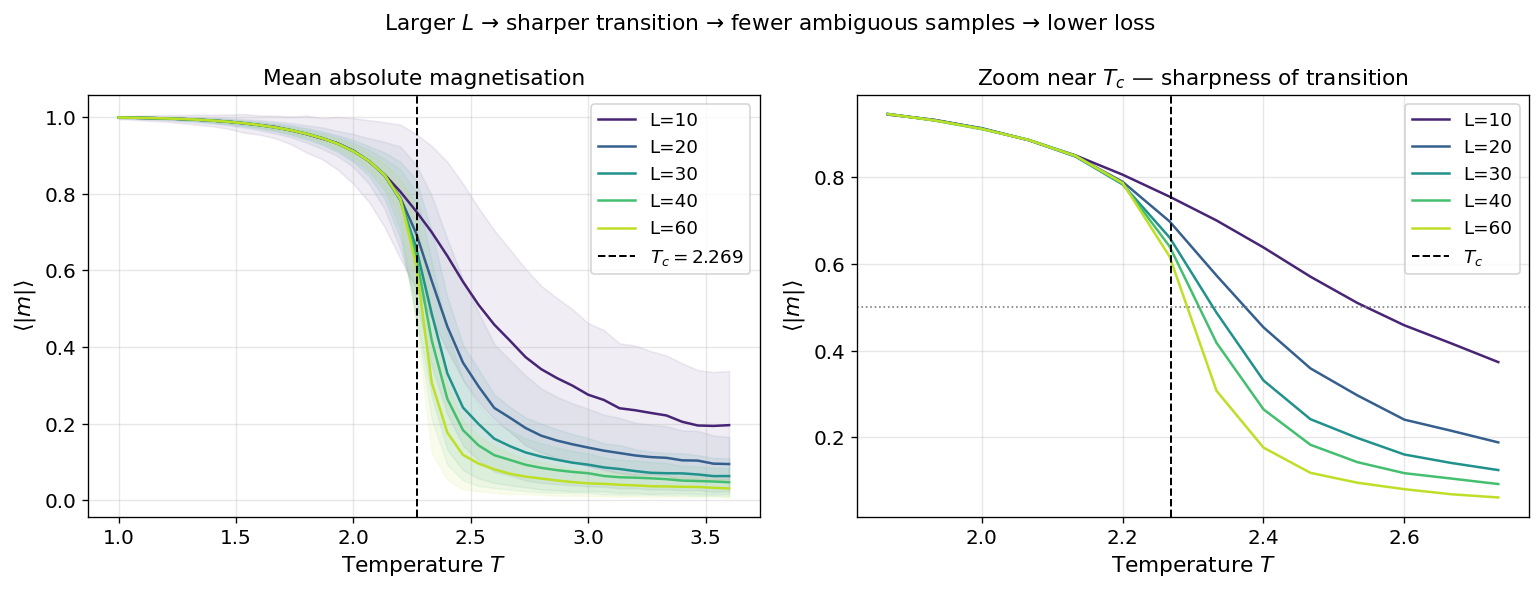

In [4]:
def magnetization_profile(L):
    data = np.load(f'data_decorr/L{L}_ising.npz')
    T    = data['temperatures']
    spins = data['spins']
    unique_T = np.unique(T)
    # mean over spins first, then abs, then average over samples
    m_mean = np.array([np.abs(spins[T == t].mean(axis=1)).mean() for t in unique_T])
    m_std  = np.array([np.abs(spins[T == t].mean(axis=1)).std()  for t in unique_T])
    return unique_T, m_mean, m_std

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: full magnetization profile
ax = axes[0]
for L, c in zip(L_values, colors):
    Tvals, m, ms = magnetization_profile(L)
    ax.plot(Tvals, m, color=c, label=f'L={L}')
    ax.fill_between(Tvals, m - ms, m + ms, color=c, alpha=0.08)
ax.axvline(Tc, color='k', ls='--', lw=1.2, label=f'$T_c={Tc:.3f}$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel(r'$\langle|m|\rangle$')
ax.set_title('Mean absolute magnetisation')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: zoom around Tc — the ambiguous zone
ax = axes[1]
for L, c in zip(L_values, colors):
    Tvals, m, ms = magnetization_profile(L)
    mask = (Tvals > 1.8) & (Tvals < 2.8)
    ax.plot(Tvals[mask], m[mask], color=c, label=f'L={L}')
ax.axvline(Tc, color='k', ls='--', lw=1.2, label=f'$T_c$')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('Temperature $T$')
ax.set_ylabel(r'$\langle|m|\rangle$')
ax.set_title('Zoom near $T_c$ — sharpness of transition')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Larger $L$ → sharper transition → fewer ambiguous samples → lower loss',
             fontsize=13)
plt.tight_layout()
plt.savefig('magnetization_profiles.pdf', bbox_inches='tight')
plt.show()

## 4  Quantifying the Ambiguous Region

A sample is "ambiguous" for the classifier when its average magnetisation is intermediate — the network cannot be confident. We define the **ambiguous fraction** as the fraction of training samples whose per-sample magnetisation lies in $[0.3, 0.7]$ (neither clearly ordered nor clearly disordered).

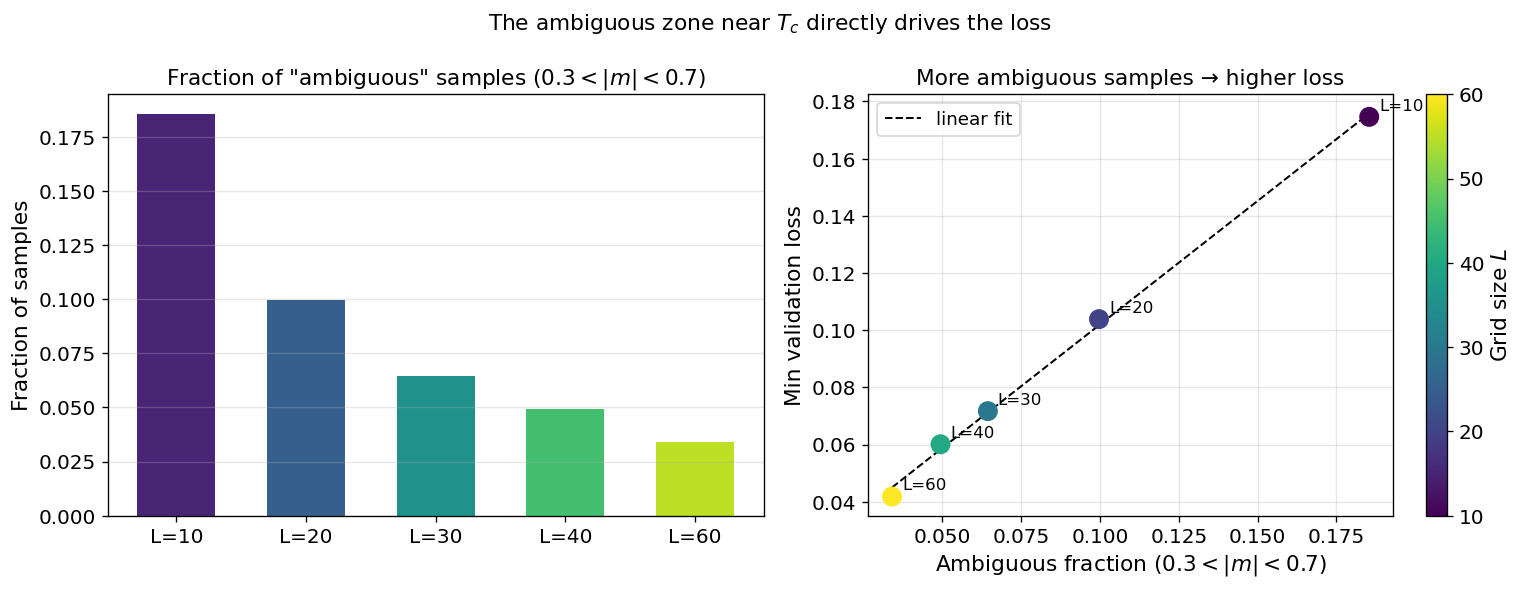

Ambiguous fractions:
  L= 10: 0.185
  L= 20: 0.100
  L= 30: 0.064
  L= 40: 0.049
  L= 60: 0.034


In [5]:
def ambiguous_fraction(L, lo=0.3, hi=0.7):
    data = np.load(f'data_decorr/L{L}_ising.npz')
    m = np.abs(data['spins'].mean(axis=1))
    return np.mean((m > lo) & (m < hi))

amb = np.array([ambiguous_fraction(L) for L in L_values])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ambiguous fraction vs L
ax = axes[0]
ax.bar(np.arange(len(L_values)), amb, color=[c for c in colors], width=0.6)
ax.set_xticks(np.arange(len(L_values)))
ax.set_xticklabels([f'L={L}' for L in L_values])
ax.set_ylabel('Fraction of samples')
ax.set_title('Fraction of "ambiguous" samples ($0.3 < |m| < 0.7$)')
ax.grid(True, axis='y', alpha=0.3)

# Scatter: ambiguous fraction vs min val loss
ax = axes[1]
mv_arr = np.array([min_val_loss[L] for L in L_values])
sc = ax.scatter(amb, mv_arr, c=Ls, cmap='viridis', s=120, zorder=3)
for L, a, v in zip(L_values, amb, mv_arr):
    ax.annotate(f'L={L}', (a, v), textcoords='offset points', xytext=(6, 4), fontsize=10)
# linear fit
p = np.polyfit(amb, mv_arr, 1)
x_fit = np.linspace(amb.min(), amb.max(), 100)
ax.plot(x_fit, np.polyval(p, x_fit), 'k--', lw=1.2, label='linear fit')
ax.set_xlabel('Ambiguous fraction ($0.3 < |m| < 0.7$)')
ax.set_ylabel('Min validation loss')
ax.set_title('More ambiguous samples → higher loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Grid size $L$')

plt.suptitle('The ambiguous zone near $T_c$ directly drives the loss',
             fontsize=13)
plt.tight_layout()
plt.savefig('ambiguous_fraction.pdf', bbox_inches='tight')
plt.show()

print('Ambiguous fractions:')
for L, a in zip(L_values, amb):
    print(f'  L={L:3d}: {a:.3f}')

## 5  Per-Temperature Loss Analysis

We can estimate where the loss comes from by computing the **theoretical minimum loss** a perfect Bayes classifier would achieve at each temperature $T$. If the class-conditional distributions overlap (i.e. a spin config at temperature $T$ could plausibly belong to either phase), even a perfect network pays a nonzero loss. We approximate this by looking at how sharply the labelling changes across the temperature axis.

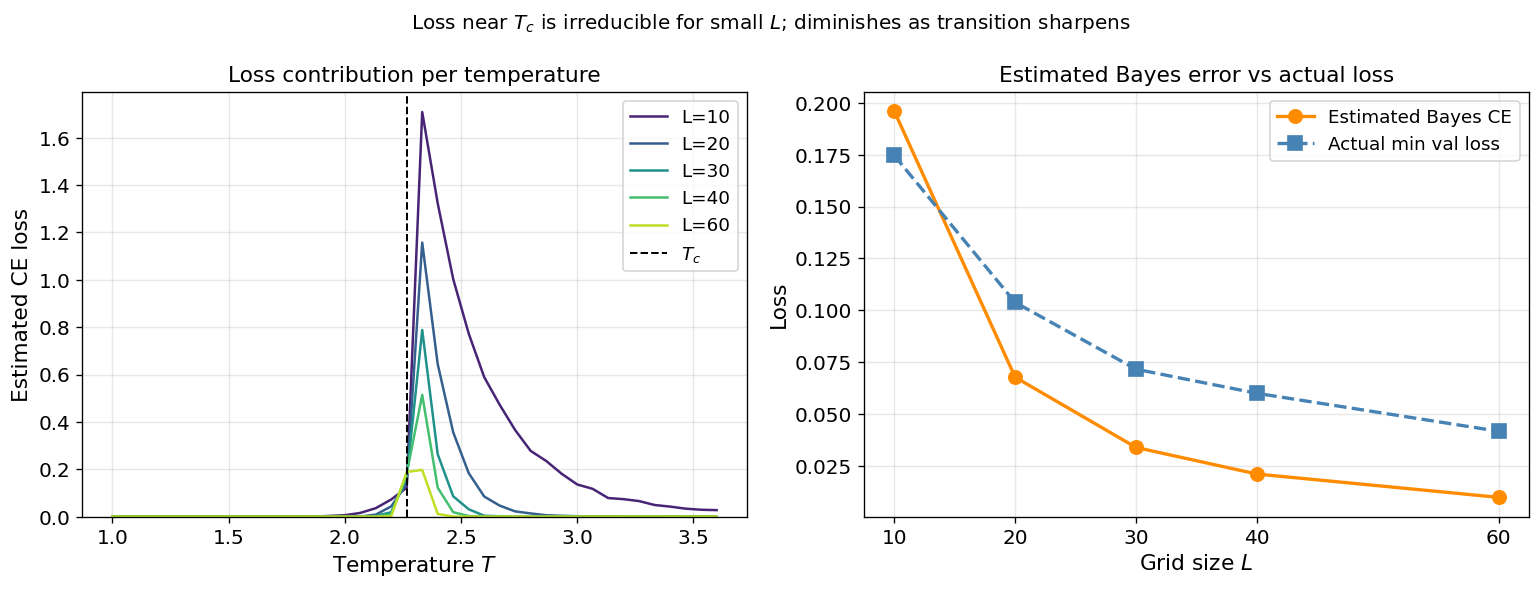

In [6]:
def label_uncertainty_profile(L):
    """
    At each temperature, estimate the cross-entropy a Bayes classifier faces:
    use fraction of samples whose per-sample |m| > 0.5 as proxy for p(ordered).
    """
    data = np.load(f'data_decorr/L{L}_ising.npz')
    T    = data['temperatures']
    spins = data['spins']
    unique_T = np.unique(T)

    ce_profile = []
    for t in unique_T:
        m_samples = np.abs(spins[T == t].mean(axis=1))
        y = 1.0 if t < Tc else 0.0
        p_ordered = np.mean(m_samples > 0.5)
        p = p_ordered if y == 1 else (1 - p_ordered)
        p = np.clip(p, 1e-7, 1 - 1e-7)
        ce_profile.append(-np.log(p))
    return unique_T, np.array(ce_profile)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: CE per temperature for each L
ax = axes[0]
for L, c in zip(L_values, colors):
    Tvals, ce = label_uncertainty_profile(L)
    ax.plot(Tvals, ce, color=c, label=f'L={L}')
ax.axvline(Tc, color='k', ls='--', lw=1.2, label=f'$T_c$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel('Estimated CE loss')
ax.set_title('Loss contribution per temperature')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

# Right: mean CE vs L
mean_ces = []
for L in L_values:
    _, ce = label_uncertainty_profile(L)
    mean_ces.append(ce.mean())

ax = axes[1]
ax.plot(L_values, mean_ces, 'o-', color='darkorange', lw=2, markersize=8, label='Estimated Bayes CE')
ax.plot(L_values, [min_val_loss[L] for L in L_values], 's--', color='steelblue',
        lw=2, markersize=8, label='Actual min val loss')
ax.set_xlabel('Grid size $L$')
ax.set_ylabel('Loss')
ax.set_title('Estimated Bayes error vs actual loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(L_values)

plt.suptitle('Loss near $T_c$ is irreducible for small $L$; diminishes as transition sharpens',
             fontsize=12)
plt.tight_layout()
plt.savefig('per_temp_loss.pdf', bbox_inches='tight')
plt.show()

## 6  Finite-Size Scaling: Width of the Critical Region

The theory predicts that the width of the critical window scales as $\delta T \sim L^{-1/\nu}$ with $\nu=1$ for the 2D Ising universality class. We can measure this empirically as the temperature range over which $\langle|m|\rangle$ drops from 0.8 to 0.2.

Transition widths per L: {10: np.float64(0.597), 20: np.float64(0.265), 30: np.float64(0.178), 40: np.float64(0.146), 60: np.float64(0.103)}
Empirical exponent: δT ~ L^-0.98  (theory: -1.00 for ν=1)


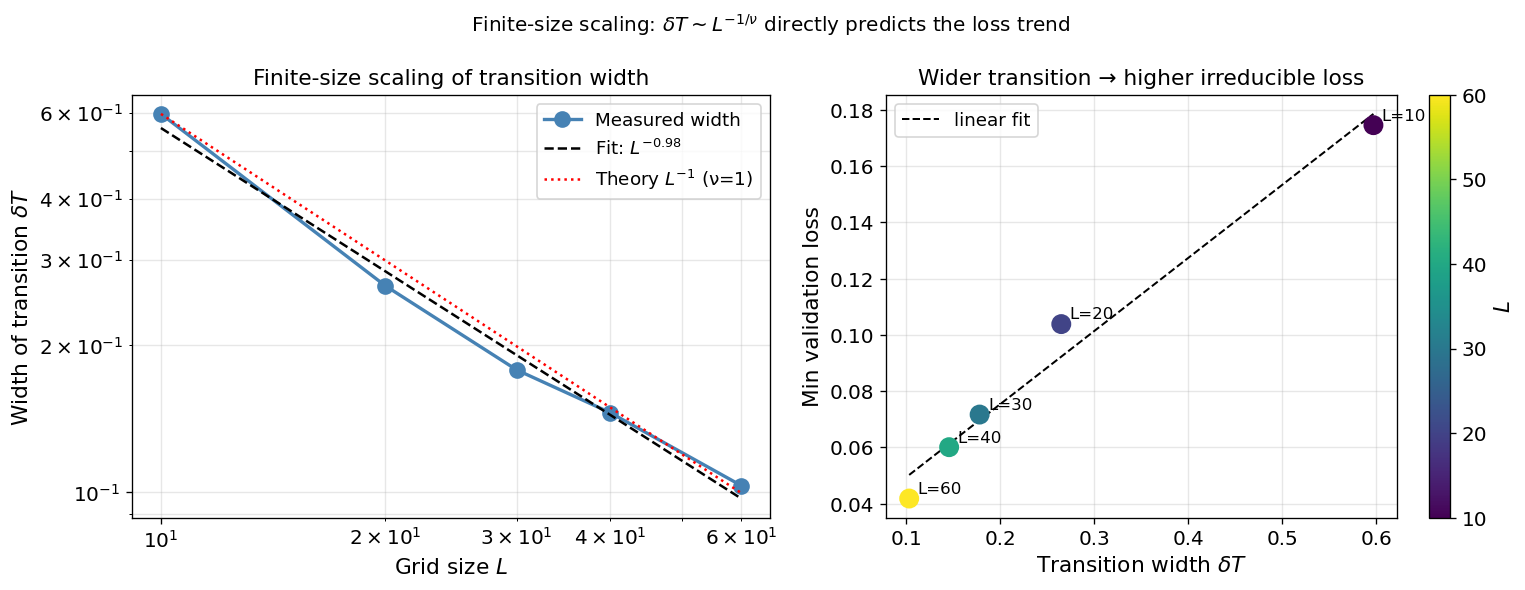

In [7]:
from scipy.interpolate import interp1d

def critical_width(L, m_hi=0.7, m_lo=0.3):
    """Temperature interval where <|m|> drops from m_hi to m_lo."""
    Tvals, m, _ = magnetization_profile(L)
    mask = Tvals > 1.5
    Tv, mv2 = Tvals[mask], m[mask]
    try:
        f = interp1d(mv2[::-1], Tv[::-1], bounds_error=False, fill_value='extrapolate')
        T_hi = float(f(m_hi))
        T_lo = float(f(m_lo))
        return abs(T_lo - T_hi)
    except Exception:
        return np.nan

widths = np.array([critical_width(L) for L in L_values])
valid  = ~np.isnan(widths)
print('Transition widths per L:', dict(zip(L_values, widths.round(3))))

# Power-law fit: width ~ L^alpha
alpha, logC = np.polyfit(np.log(Ls[valid]), np.log(widths[valid]), 1)
print(f'Empirical exponent: δT ~ L^{alpha:.2f}  (theory: -1.00 for ν=1)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(Ls[valid], widths[valid], 'o-', color='steelblue', lw=2, markersize=9,
          label='Measured width')
L_fit = np.linspace(Ls.min(), Ls.max(), 100)
ax.loglog(L_fit, np.exp(logC) * L_fit**alpha, 'k--', lw=1.5,
          label=f'Fit: $L^{{{alpha:.2f}}}$')
# Theory line: L^{-1}, normalised to pass through L=10 point
C_theory = widths[0] * Ls[0]**1.0
ax.loglog(L_fit, C_theory * L_fit**(-1.0), 'r:', lw=1.5, label='Theory $L^{-1}$ (ν=1)')
ax.set_xlabel('Grid size $L$')
ax.set_ylabel('Width of transition $\\delta T$')
ax.set_title('Finite-size scaling of transition width')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

mv_arr = np.array([min_val_loss[L] for L in L_values])

ax = axes[1]
sc = ax.scatter(widths[valid], mv_arr[valid], c=Ls[valid], cmap='viridis', s=120, zorder=3)
for L, w, v in zip(Ls[valid], widths[valid], mv_arr[valid]):
    ax.annotate(f'L={L}', (w, v), textcoords='offset points', xytext=(5, 3), fontsize=10)
p2 = np.polyfit(widths[valid], mv_arr[valid], 1)
xf = np.linspace(widths[valid].min(), widths[valid].max(), 100)
ax.plot(xf, np.polyval(p2, xf), 'k--', lw=1.2, label='linear fit')
ax.set_xlabel('Transition width $\\delta T$')
ax.set_ylabel('Min validation loss')
ax.set_title('Wider transition → higher irreducible loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='$L$')

plt.suptitle('Finite-size scaling: $\\delta T \\sim L^{-1/\\nu}$ directly predicts the loss trend',
             fontsize=12)
plt.tight_layout()
plt.savefig('fss_scaling.pdf', bbox_inches='tight')
plt.show()

## 7  Summary

### Physical explanation

The binary cross-entropy loss of the Ising classifier decreases with grid size $L$ for three interlocking reasons, all rooted in **finite-size scaling**:

| Mechanism | Small $L$ | Large $L$ |
|---|---|---|
| Width of critical region | Wide: $\delta T \sim L^{-1}$ large | Narrow: most samples unambiguous |
| Magnetisation signal | Smeared, large fluctuations relative to mean | Sharp step; well-ordered away from $T_c$ |
| Input information | $L^2$ spin features | $L^2$ spin features (more data per sample) |

### Mathematical picture

The cross-entropy loss is large only when the network is **uncertain**, i.e. when $p \approx 0.5$. This happens only near $T_c$, where the order parameter has not yet chosen a phase. For a lattice of size $L$, the fraction of training temperatures that fall in this uncertain window scales as $\sim L^{-1/\nu}$ (with $\nu=1$ for 2D Ising). Therefore the **average loss over the training set** decays as a power law in $L$.

This is not a limitation of the network — it is a fundamental, **irreducible (Bayes) error** imposed by the physics: for small $L$, even an omniscient classifier cannot determine the phase of configurations near $T_c$ because the finite lattice simply has not decided which phase it is in.

The key paper that introduced this approach is:
> Carrasquilla & Melko, *Machine learning phases of matter*, **Nature Physics** 13, 431 (2017)  
> — they explicitly note that the output neuron of the trained network sharpens around $T_c$ as $L$ increases, reflecting the sharpening phase transition.

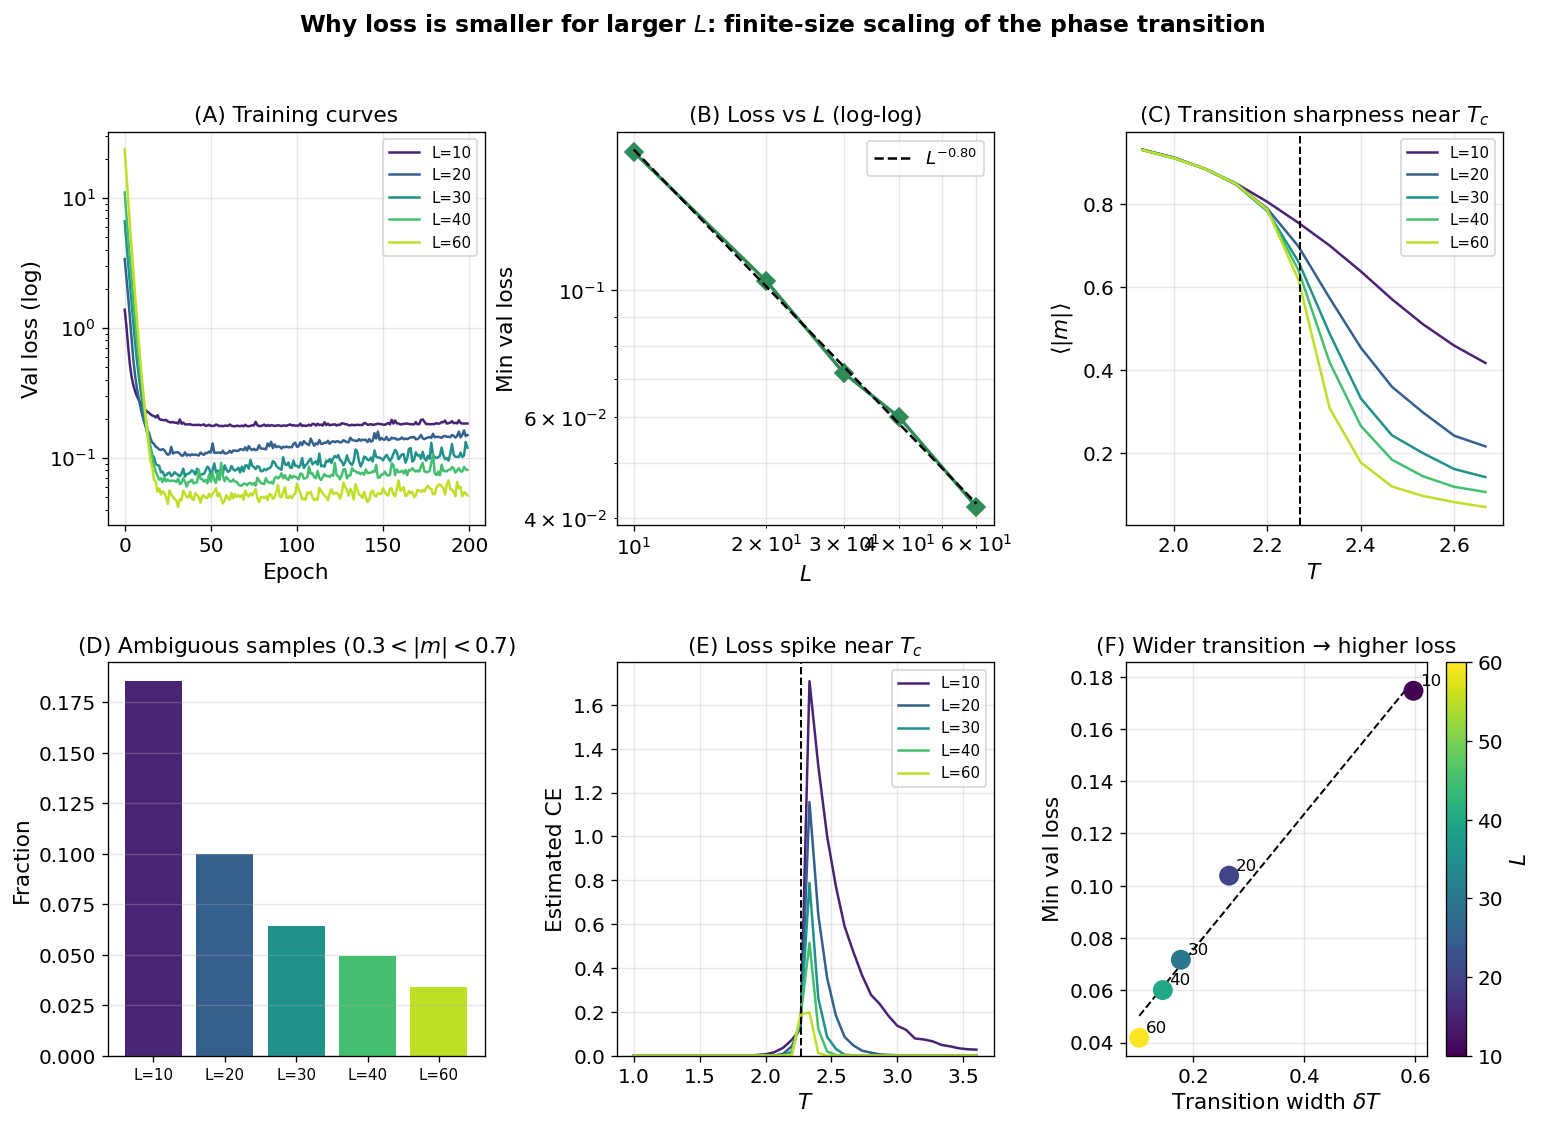

Saved summary_figure.pdf


In [8]:
# One combined summary figure
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# (A) Training curves
ax = fig.add_subplot(gs[0, 0])
for L, c in zip(L_values, colors):
    ax.semilogy(histories[L]['val_loss'], color=c, label=f'L={L}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val loss (log)')
ax.set_title('(A) Training curves')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (B) Min loss vs L (log-log)
mv_arr = np.array([min_val_loss[L] for L in L_values])
slope, intercept = np.polyfit(np.log(Ls), np.log(mv_arr), 1)

ax = fig.add_subplot(gs[0, 1])
ax.loglog(Ls, mv_arr, 'D-', color='seagreen', lw=2, markersize=8)
L_fit2 = np.linspace(Ls.min(), Ls.max(), 100)
ax.loglog(L_fit2, np.exp(intercept)*L_fit2**slope, 'k--', lw=1.5,
          label=f'$L^{{{slope:.2f}}}$')
ax.set_xlabel('$L$'); ax.set_ylabel('Min val loss')
ax.set_title('(B) Loss vs $L$ (log-log)')
ax.legend(); ax.grid(True, alpha=0.3, which='both')

# (C) Magnetisation zoom near Tc
ax = fig.add_subplot(gs[0, 2])
for L, c in zip(L_values, colors):
    Tv, m_prof, ms = magnetization_profile(L)
    mask = (Tv > 1.9) & (Tv < 2.7)
    ax.plot(Tv[mask], m_prof[mask], color=c, label=f'L={L}')
ax.axvline(Tc, color='k', ls='--', lw=1.2)
ax.set_xlabel('$T$'); ax.set_ylabel(r'$\langle|m|\rangle$')
ax.set_title('(C) Transition sharpness near $T_c$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (D) Ambiguous fraction
ax = fig.add_subplot(gs[1, 0])
ax.bar(np.arange(len(L_values)), amb,
       color=[colors[i] for i in range(len(L_values))])
ax.set_xticks(np.arange(len(L_values)))
ax.set_xticklabels([f'L={L}' for L in L_values], fontsize=9)
ax.set_ylabel('Fraction'); ax.set_title('(D) Ambiguous samples ($0.3<|m|<0.7$)')
ax.grid(True, axis='y', alpha=0.3)

# (E) Per-temp CE for all L
ax = fig.add_subplot(gs[1, 1])
for L, c in zip(L_values, colors):
    Tv, ce = label_uncertainty_profile(L)
    ax.plot(Tv, ce, color=c, label=f'L={L}')
ax.axvline(Tc, color='k', ls='--', lw=1.2)
ax.set_xlabel('$T$'); ax.set_ylabel('Estimated CE')
ax.set_title('(E) Loss spike near $T_c$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

# (F) Transition width vs min loss
ax = fig.add_subplot(gs[1, 2])
sc = ax.scatter(widths[valid], mv_arr[valid], c=Ls[valid], cmap='viridis', s=120, zorder=3)
for L, w, v in zip(Ls[valid], widths[valid], mv_arr[valid]):
    ax.annotate(f'{L}', (w, v), textcoords='offset points', xytext=(4, 3), fontsize=10)
p2 = np.polyfit(widths[valid], mv_arr[valid], 1)
xf = np.linspace(widths[valid].min(), widths[valid].max(), 100)
ax.plot(xf, np.polyval(p2, xf), 'k--', lw=1.2)
ax.set_xlabel('Transition width $\\delta T$')
ax.set_ylabel('Min val loss')
ax.set_title('(F) Wider transition → higher loss')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='$L$')

plt.suptitle('Why loss is smaller for larger $L$: finite-size scaling of the phase transition',
             fontsize=14, fontweight='bold')
plt.savefig('summary_figure.pdf', bbox_inches='tight')
plt.show()
print('Saved summary_figure.pdf')